# Held-out validation of SCOUT-EM by masking part of the tree

`runSCOUT.dropout()` asks whether SCOUT's latent expression is actually informative: it masks part of the tree, refits SCOUT-EM on the reduced tree, and then predicts the masked tips' expression **from the retained tips alone**. If that prediction beats a no-phylogeny baseline, the OU-on-tree covariance is carrying real information.

### The estimator

SCOUT's `e_step` computes the posterior over all tips jointly, `E_Z = Wθ + V(V + τ²I)⁻¹(X − Wθ)`. Splitting tips into retained `o` and held-out `h`, the same Gaussian algebra gives

```
E[Z_h | X_o]   = W_hθ + V_ho (V_oo + τ²I)⁻¹ (X_o − W_oθ)
Var[Z_h | X_o] = V_hh    − V_ho (V_oo + τ²I)⁻¹ V_oh
```

`X_h` never enters, and the parameters come from a fit that never saw those tips. The variance term gives prediction intervals, so we can report coverage as well as RMSE.

### Two masking arms

For any tip `i` in a dropped clade and any retained tip `o`, `MRCA(i, o)` is the same node regardless of which `i` you pick, so `V[i,o] = exp(−α·t_i)·g(o)` and **`V_ho` is rank one**. The correction collapses to a single scalar, and on an ultrametric tree predictions within the clade are constant up to the regime-weight term. That is correct model behaviour — a monophyletic clade joins the rest of the tree through one branch — but it means per-tip RMSE inside a clade is floored by irreducible within-clade variance.

So two arms are run per replicate:

| Arm | Mask | `V_ho` | Demonstrates |
|---|---|---|---|
| `clade` | all tips under a sampled node | rank 1 | clade-level recovery, interval coverage |
| `random` | the same number of tips, scattered | full rank | per-tip RMSE and correlation |

Judge the result against the **baselines**, not against absolute RMSE:

| Predictor | Meaning |
|---|---|
| `masked` | the estimand — masked-fit parameters, retained tips only |
| `prior` | `W_hθ` alone, no phylogenetic borrowing — **the null to beat** |
| `oracle` | same estimator with full-tree parameters — did masking hurt the fit? |
| `global` | mean of the retained tips — crude floor |

In [7]:
detach("package:SCOUT", unload = TRUE)

In [4]:
library(SCOUT)
library(ape)
library(castor)
library(dplyr)
library(ggplot2)

Warning message:
“multiple methods tables found for ‘union’”
Warning message:
“multiple methods tables found for ‘intersect’”
Warning message:
“multiple methods tables found for ‘setdiff’”
Warning message:
“multiple methods tables found for ‘setequal’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘SummarizedExperiment’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘IRanges’”
Warning message:
“multiple methods tables found for ‘union’”
Warning message:
“multiple methods tables found for ‘intersect’”
Warning message:
“multiple methods tables found for ‘setdiff’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘GenomeInfoDb’”
Warning message:
“multiple methods tables found for ‘intersect’”
Warning message:
“replacing previous import ‘BiocGenerics::setequal’ by ‘S4Vectors::setequal’ when loading ‘GenomicRanges

## 1. Build a tree

Same setup as `260804_sim_test_2.ipynb`: a birth-death tree with regimes painted on by a Markov model, then ancestral states inferred so the simulator has labelled internal nodes.

In [5]:
set.seed(1)
ncells <- 100
P <- matrix(c(0.90, 0.08, 0.02,
              0.10, 0.80, 0.10,
              0.02, 0.08, 0.90), 3, 3, byrow = TRUE)
Q <- expm::logm(P)

simtree.obj <- generate_tree_hbd_reverse(ncells, rho = 1, lambda = 1, mu = 0)
simtree <- simtree.obj$trees[[1]]
simtree$tip.label <- paste0('t', simtree$tip.label)
states <- simulate_mk_model(simtree, Q = Q, include_nodes = FALSE)
simtree$states <- as.factor(paste0('state', states$tip_states))
simtree <- infer_anc(simtree)

table(simtree$states)


state1 state2 state3 
    42     14     44 

## 2. Run the dropout validation

With `sim_res = NULL` the function simulates internally on this tree, so one call goes from newick to scored predictions. Every replicate reuses that single simulation, which isolates the effect of *which* tips were masked from simulation noise.

Two settings worth understanding:

- **`t0` must be large enough that the simulated traits stay positive.** `m_step_tipfog` bounds `theta` below at `1e-10`, so a gene whose true mean is near or below zero cannot be fit. BM1 genes drift with variance `sigma^2 * tree_height`, so `t0` needs roughly `3 * s * sqrt(height)` of headroom. The function warns if any simulated value is non-positive.
- **Tree scaling is forced off.** `scaleHeight` divides edge lengths by `Tmax`, which would put the masked tree's `alpha` and `sigma` on a different time scale from the full tree's covariance and break the parameter transfer.

In [9]:
res <- runSCOUT.dropout(
    tree          = simtree,
    results_dir   = '../../../../OU//revisions_analysis/revision_v2/2_dropout_output',
    n_replicates  = 10,
    clade_min     = 5,
    clade_max     = 20,
    arms          = c('clade', 'random'),
    ngenes        = 10,   # genes for the beta-Poisson counts matrix
    nevfs         = 10,   # latent OU traits -- these are what we score against
    a = 3, s = 1, t0 = 8, theta_step = 2,
    randseed      = 42,
    cores         = 8
)

lapply(res[c('clades', 'predictions', 'metrics', 'params', 'model_select')], dim)

Directory created: ../../../../OU//revisions_analysis/revision_v2/2_dropout_output 


2026-08-06 11:59:15.686471 | Dropout validation run ID = SCOUTDROP_MA0o9zhV

2026-08-06 11:59:15.689905 | Data will be saved to --> ../../../../OU//revisions_analysis/revision_v2/2_dropout_output

2026-08-06 11:59:15.691632 | =========================================================


2026-08-06 11:59:15.693703 | Tree has 100 tips across 3 regimes.



Directory created: ../../../../OU//revisions_analysis/revision_v2/2_dropout_output/simulated_data 


2026-08-06 11:59:15.700995 | Simulating expression on the complete tree.

2026-08-06 11:59:15.70477 | Simulating OU genes for 1 parameter combinations.

2026-08-06 11:59:16.627944 | Data generation complete

2026-08-06 11:59:16.63008 | Preparing the complete tree.

2026-08-06 11:59:16.63186 | Inferring gene list from input data columns.

2026-08-06 11:59:16.633222 | 30 genes were detected. 

2026-08-06 11:59:16.635428 | 100 leaves were found in the raw tree. 100 leaves intersect with species column.

2026-08-06 11:59:16.63682 | Preprocessing tree

2026-08-06 11:59:16.638115 | Found edge lengths.

2026-08-06 11:59:16.639775 | Regime: BM1 Rcol: OU1 Model: BM1

2026-08-06 11:59:16.641102 | Regime: OU1 Rcol: OU1 Model: OU1

2026-08-06 11:59:16.70637 | Regime: OUM Rcol: OUM Model: OUM

2026-08-06 11:59:17.044054 | Fitting SCOUT-EM on the complete tree (reference).



Running 90 combinations. Results will be saved at run ID = SCOUTDROP_MA0o9zhV_full 


...

Running 90 combinations. Results will be saved at run ID = SCOUTDROP_MA0o9zhV_r010_clade 


2026-08-06 12:54:00.45362 | Start time = 12:54:00


2026-08-06 12:56:27.729451 | End time = 12:56:27


2026-08-06 12:56:28.729191 | Replicate 10 | arm random | masking 7 of 100 tips.

2026-08-06 12:56:28.733902 | Inferring gene list from input data columns.

2026-08-06 12:56:28.735646 | 30 genes were detected. 

2026-08-06 12:56:28.738528 | 93 leaves were found in the raw tree. 93 leaves intersect with species column.

2026-08-06 12:56:28.740145 | Preprocessing tree

2026-08-06 12:56:28.74159 | Found edge lengths.

2026-08-06 12:56:28.743541 | Regime: BM1 Rcol: OU1 Model: BM1

2026-08-06 12:56:28.745071 | Regime: OU1 Rcol: OU1 Model: OU1

2026-08-06 12:56:28.805391 | Regime: OUM Rcol: OUM Model: OUM



Running 90 combinations. Results will be saved at run ID = SCOUTDROP_MA0o9zhV_r010_random 


2026-08-06 12:56:29.138223 | Start time = 12:56:29


2026-08-06 13:01:03.961118 | End time = 13:01:03


2026-08-06 13:01:07.1751 | Dropout validation complete. 7200 metric rows written.



$clades
[1] 20  6

$predictions
[1] 5760   11

$metrics
[1] 7200   17

$params
[1] 1800   17

$model_select
[1] 600   6

## 3. Did the model beat the no-phylogeny baseline?

Restrict to the regime that actually generated each gene, then compare predictors within each arm.

In [10]:
m <- res$metrics %>% filter(regime == true_model)

m %>%
  group_by(arm, predictor) %>%
  summarise(rmse       = mean(rmse, na.rm = TRUE),
            clade_mean_err = mean(abs(mean_error), na.rm = TRUE),
            pearson    = mean(pearson, na.rm = TRUE),
            coverage95 = mean(coverage, na.rm = TRUE),
            .groups = 'drop') %>%
  arrange(arm, rmse)

arm,predictor,rmse,clade_mean_err,pearson,coverage95
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
clade,oracle,0.6573377,0.3542449,0.1838556,0.6874696
clade,masked,0.6615761,0.3625414,0.1157888,0.6859769
clade,prior,0.7646131,0.4740869,0.5075435,NaN
clade,global,1.3245920,1.0650906,NaN,NaN
random,oracle,0.4829236,0.1333711,0.7440633,0.7012318
random,masked,0.4899550,0.1386887,0.7421414,0.6989080
random,prior,0.8111309,0.2860160,0.9770449,NaN
random,global,1.3003321,0.3552459,NaN,NaN


**How to read this.** In the `random` arm, `masked` should beat `prior` on RMSE and show a clear positive `pearson` — that is per-tip recovery. In the `clade` arm, `pearson` is undefined or near zero *by construction* (rank-one `V_ho`); the informative column is `clade_mean_err`, the error in the clade's overall level. `masked ≈ oracle` means masking did not degrade the parameter estimates. `coverage95` near 0.95 means the posterior intervals are calibrated.

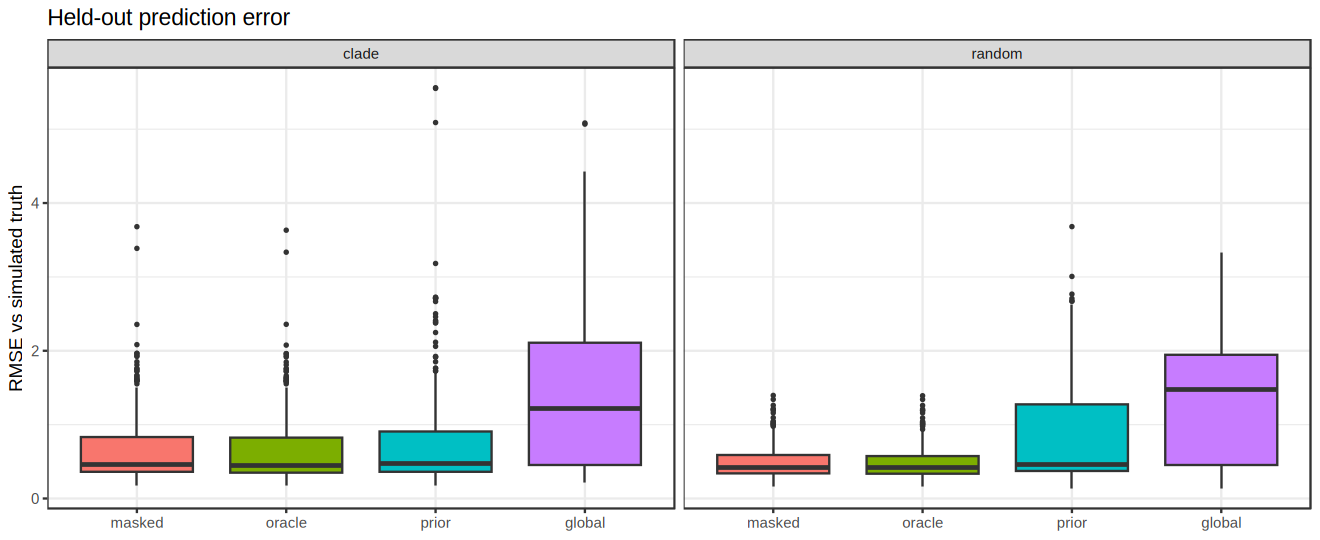

In [11]:
options(repr.plot.width = 11, repr.plot.height = 4.5)

m %>%
  filter(predictor %in% c('masked', 'prior', 'oracle', 'global')) %>%
  mutate(predictor = factor(predictor, levels = c('masked', 'oracle', 'prior', 'global'))) %>%
  ggplot(aes(predictor, rmse, fill = predictor)) +
    geom_boxplot(outlier.size = 0.5) +
    facet_grid(. ~ arm) +
    labs(title = 'Held-out prediction error', y = 'RMSE vs simulated truth', x = NULL) +
    theme_bw() + theme(legend.position = 'none')

## 4. Per-tip recovery

`res$predictions` holds one row per masked tip. The flat band in the `clade` panel is the rank-one collapse, not a failure.

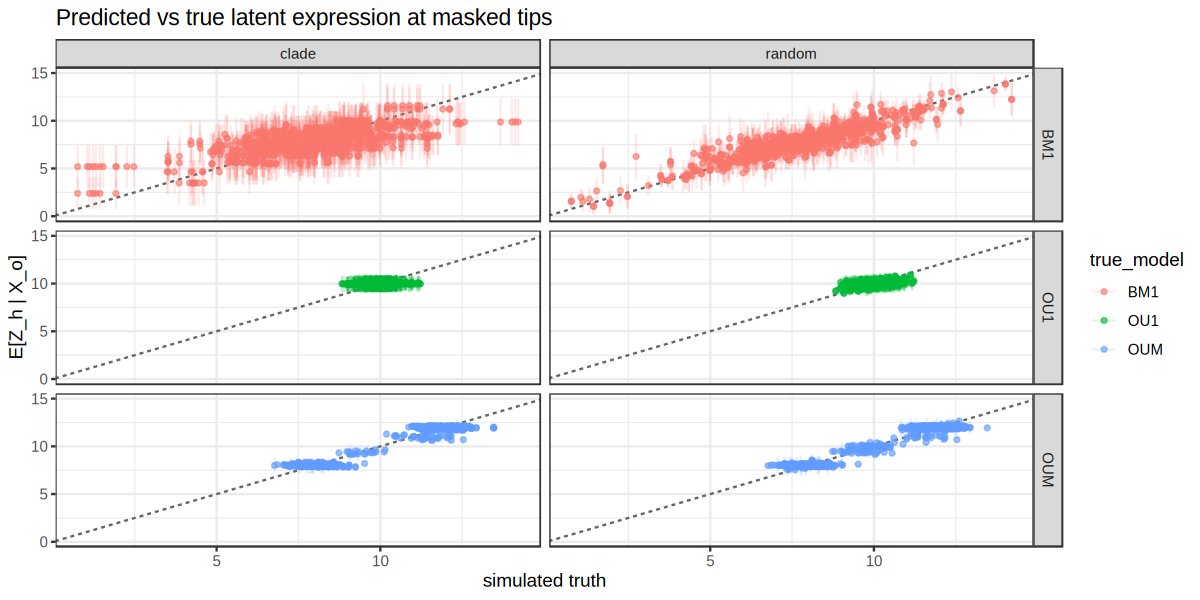

In [12]:
options(repr.plot.width = 10, repr.plot.height = 5)

ggplot(res$predictions, aes(z_true, z_masked, colour = true_model)) +
  geom_abline(slope = 1, intercept = 0, linetype = 2, colour = 'grey40') +
  geom_errorbar(aes(ymin = z_masked - 1.96*pred_sd, ymax = z_masked + 1.96*pred_sd),
                alpha = 0.15, width = 0) +
  geom_point(alpha = 0.6, size = 1) +
  facet_grid(true_model ~ arm) +
  labs(title = 'Predicted vs true latent expression at masked tips',
       x = 'simulated truth', y = 'E[Z_h | X_o]') +
  theme_bw()

#### a. Manual look into predictions 

regime,n,MSE,rMSE,cor_coef
<chr>,<int>,<dbl>,<dbl>,<dbl>
BM1,960,0.6188272,0.7866557,0.9124864
OU1,960,0.1306165,0.3614091,0.4658893
OUM,960,0.1768559,0.4205424,0.9760545


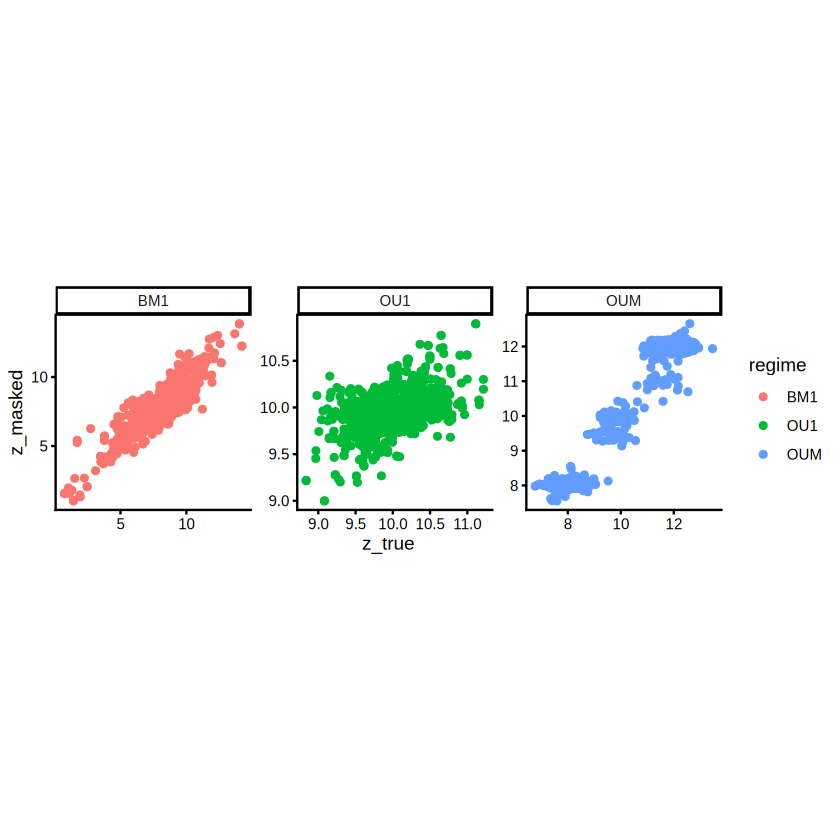

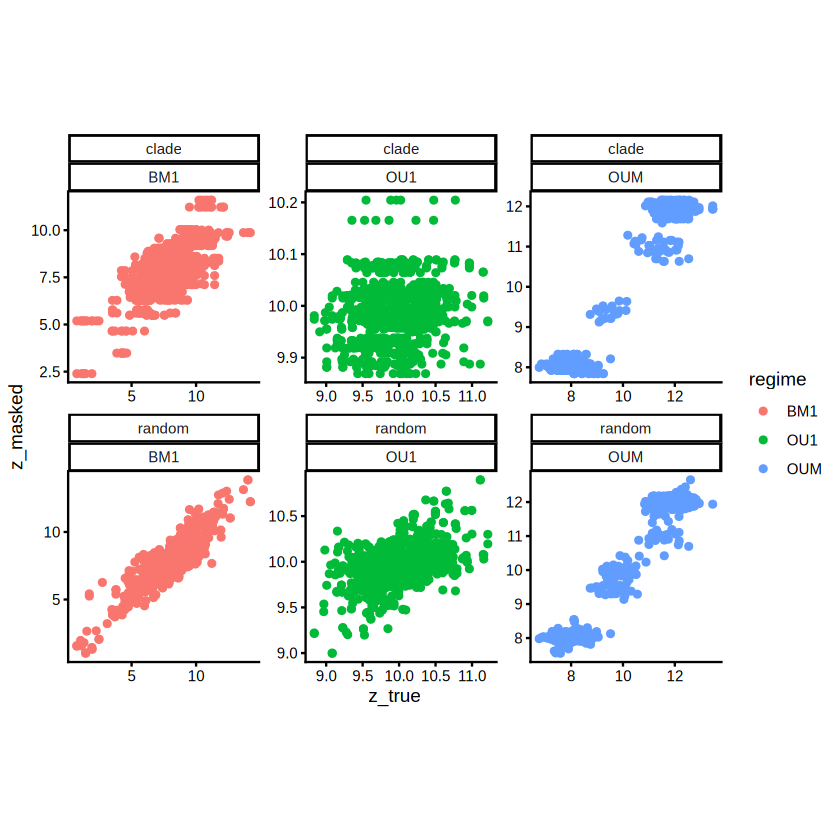

In [20]:
preds <- read.csv('../../../../OU/revisions_analysis/revision_v2/2_dropout_output/SCOUTDROP_MA0o9zhV_20260806_predictions.csv')
#head(preds)

rpreds <- preds %>% filter(arm == 'random') %>% mutate(z_diff = z_true-z_masked)
summ.preds <- rpreds %>% 
    group_by(regime) %>% summarize(n = n(), MSE = mean(z_diff^2), 
                                   rMSE = sqrt(MSE),
                                   cor_coef  = cor(z_true, z_masked))
summ.preds
ggplot(rpreds, aes(x = z_true, y = z_masked, color = regime)) + geom_point() + 
    facet_wrap(.~regime, scales = 'free') + theme_classic() + theme(aspect.ratio = 1)

ggplot(preds, aes(x = z_true, y = z_masked, color = regime)) + geom_point() + 
    facet_wrap(arm~regime, scales = 'free') + theme_classic() + theme(aspect.ratio = 1)

## 5. Does masking change model selection?

A separate question from prediction accuracy: with a clade removed, does SCOUT still pick the same model class? AIC here is computed from the true tip count of each masked tree, not the hardcoded 256 in `annotate_history`.

In [13]:
with(res$model_select, table(full = best_full, masked = best_masked))

res$model_select %>%
  group_by(arm) %>%
  summarise(agreement_with_full = mean(best_masked == best_full, na.rm = TRUE),
            accuracy_vs_truth   = mean(best_masked == true_model, na.rm = TRUE),
            .groups = 'drop')

     masked
full  BM1 OU1 OUM
  BM1 201   0  19
  OU1   7 161  12
  OUM   7   0 193

arm,agreement_with_full,accuracy_vs_truth
<chr>,<dbl>,<dbl>
clade,0.92,0.9200000
random,0.93,0.9166667


## 6. Parameter stability

`res$params` carries the masked-fit and full-fit parameters side by side, so you can see directly whether removing a clade moved `alpha`, `sigma` or `tau`.

In [14]:
res$params %>%
  filter(regime == true_model) %>%
  group_by(arm, true_model) %>%
  summarise(across(c(alpha, alpha_full, sigma, sigma_full, tau, tau_full),
                   ~ round(median(.x, na.rm = TRUE), 3)),
            not_converged = sum(is.na(converge)),
            .groups = 'drop')

arm,true_model,alpha,alpha_full,sigma,sigma_full,tau,tau_full,not_converged
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
clade,BM1,0.000,0.000,0.618,0.615,0.288,0.288,0
clade,OU1,1.189,1.191,0.368,0.371,0.077,0.076,0
clade,OUM,1.573,1.548,0.010,0.010,0.307,0.312,3
random,BM1,0.000,0.000,0.617,0.615,0.291,0.288,0
random,OU1,1.194,1.191,0.371,0.371,0.077,0.076,0
random,OUM,1.523,1.548,0.010,0.010,0.309,0.312,3
